In [ ]:
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.image import resize
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import plot_model

# Loading Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define paths for the dataset
zip_path = '/content/drive/MyDrive/TVSum Dataset/ydata-tvsum50-video.zip'
extract_dir = '/content/drive/MyDrive/TVSum Dataset/tvsum_videos'

In [ ]:
# os.makedirs(extract_dir, exist_ok=True)

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# print("Extraction complete!")

In [ ]:
# Create directories for storing extracted frames
frames_dir = '/content/drive/MyDrive/TVSum Dataset/frames'
train_frames_dir = os.path.join(frames_dir, 'train')
test_frames_dir = os.path.join(frames_dir, 'test')
os.makedirs(frames_dir, exist_ok=True)

# Frames Extraction

In [ ]:
# frames extraction functions
def extract_frames(video_path, output_dir, fps=1):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0
    video_fps = int(cap.get(cv2.CAP_PROP_FPS))
    success, frame = cap.read()
    while success:
       # Save frame at the specified intervals (every 1 second)
        if frame_count % max(1, video_fps // fps) == 0:
            frame_file = os.path.join(output_dir, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(frame_file, frame)
            saved_count += 1
        frame_count += 1
        success, frame = cap.read()

    cap.release()
    print(f"Extracted {saved_count} frames out of {frame_count} frames from {os.path.basename(video_path)}")

In [ ]:
#extracting frames from training videos
# vid_dir = '/content/drive/MyDrive/TVSum Dataset/tvsum_videos/video'
# for video_file in os.listdir(vid_dir):
#     if video_file.endswith('.mp4'):
#         video_path = os.path.join(vid_dir, video_file)
#         output_dir = os.path.join(train_frames_dir, os.path.splitext(video_file)[0])
#         extract_frames(video_path, output_dir, fps=1)

#Extract frames from test video
# extract_frames('/content/drive/MyDrive/TVSum Dataset/tvsum_videos/test/uGu_10sucQo.mp4',test_frames_dir)

# Preprocessing

In [ ]:
frames_dir = '/content/drive/MyDrive/TVSum Dataset/frames/train'
X = []
for video_folder in os.listdir(frames_dir):
    video_path = os.path.join(frames_dir, video_folder)
     # Skip if not a directory
    if not os.path.isdir(video_path):
        continue
    for frame_file in sorted(os.listdir(video_path)):
        frame_path = os.path.join(video_path, frame_file)
        img = cv2.imread(frame_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # changing from BGR to RGB
        img = cv2.resize(img, (64,64))  # Resizing the dataset
        X.append(img)

In [ ]:
#Convering the x to a numpy array
X = np.array(X, dtype=np.uint8)

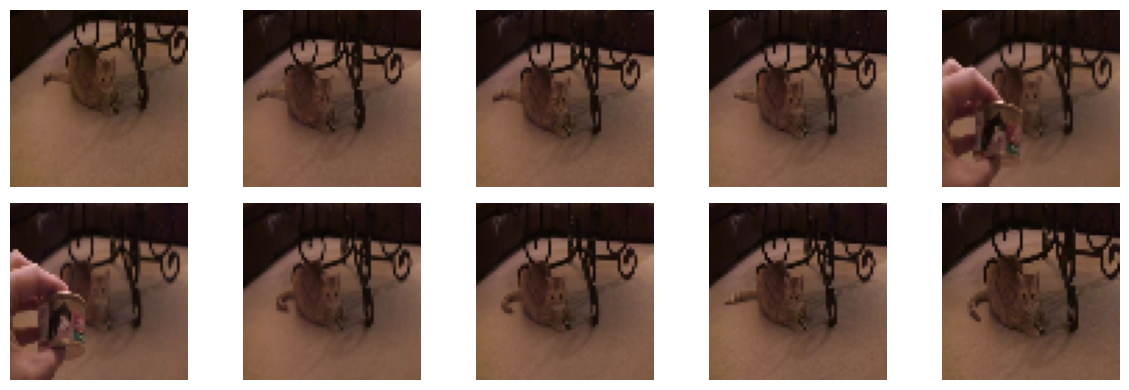

In [ ]:
#sample frames
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#preprocessing test data
test_frames_dir = '/content/drive/MyDrive/TVSum Dataset/frames/test'
x_test =[]
frame_files = sorted(os.listdir(test_frames_dir))[:30] # Load only the first 30 frames from the test video
for frame_file in frame_files:
    frame_path = os.path.join(test_frames_dir, frame_file)
    img = cv2.imread(frame_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))
    x_test.append(img)
x_test = np.array(x_test, dtype=np.uint8)

In [ ]:
print(X.shape)
print(x_test.shape)

(12757, 64, 64, 3)
(30, 64, 64, 3)


In [ ]:
X = np.array(X, dtype=np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

In [ ]:
# Splitting the data into train and validation sets
x_train, x_val= train_test_split(X, test_size=0.10, random_state=42)

In [ ]:
print('X train shape: ', x_train.shape)
print('X validation shape: ', x_val.shape)

X train shape:  (11481, 64, 64, 3)
X validation shape:  (1276, 64, 64, 3)


# Convolutional Autencoder

In [ ]:
image_size = (64,64,3)
input = Input(shape=image_size)
#Encoder
encoded = Conv2D(32,3,activation='relu',padding='same')(input)
encoded = MaxPooling2D(2, padding="same")(encoded)
encoded = Conv2D(64, 3, activation="relu", padding="same")(encoded)
encoded = MaxPooling2D(2, padding="same")(encoded)
encoded = Conv2D(128, 3, activation="relu", padding="same")(encoded)
encoded_out = MaxPooling2D(2, padding="same")(encoded)

In [ ]:
#Decoder
decoded = Conv2D(128, 3, activation="relu", padding="same")(encoded_out)
decoded = UpSampling2D(2)(decoded)
decoded= Conv2D(64, 3, activation="relu", padding="same")(decoded)
decoded = UpSampling2D(2)(decoded)
decoded = Conv2D(32, 3, activation="relu", padding="same")(decoded)
decoded = UpSampling2D(2)(decoded)
decoded_out = Conv2D(3, 3, activation="sigmoid", padding="same")(decoded)

In [ ]:
#Model creation and compilation
conv_ae = Model(input,decoded_out)
conv_ae.compile(optimizer="adam", loss="mse")
conv_ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

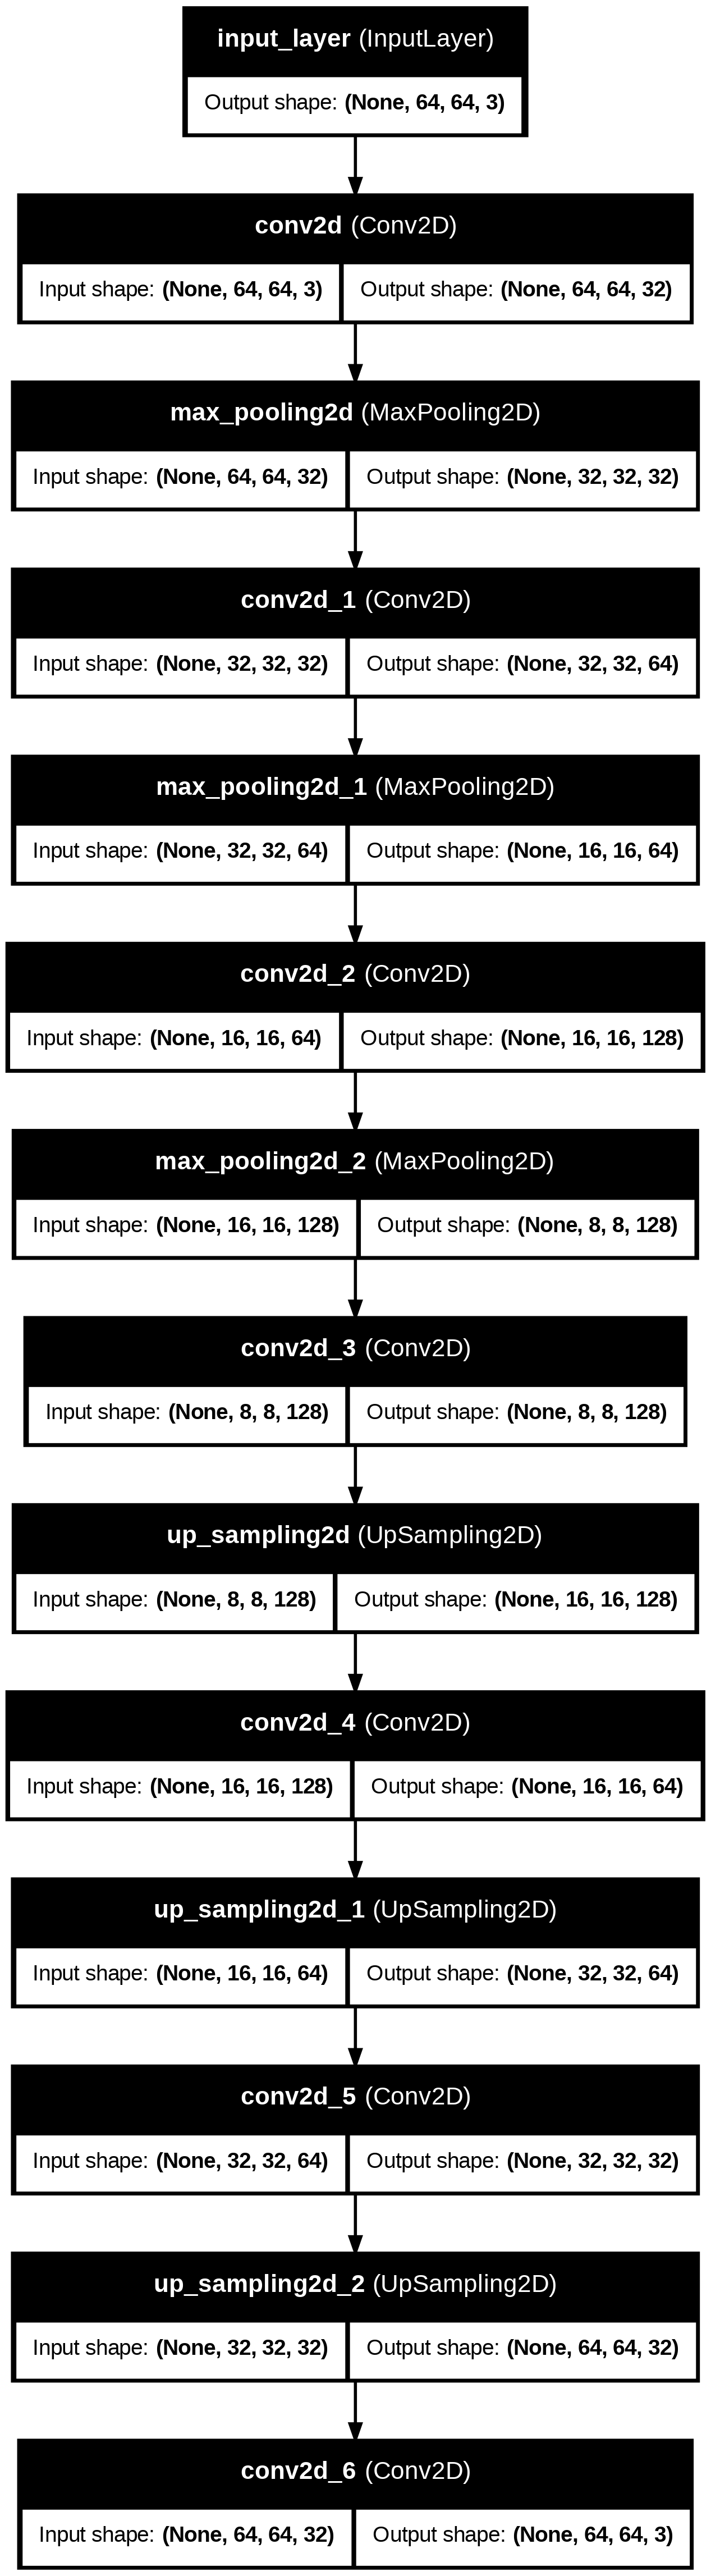

In [ ]:
#Model plotting
plot_model(conv_ae, show_shapes=True, show_layer_names=True)

In [ ]:
#Model training
history = conv_ae.fit(x_train,x_train,
                      validation_data=(x_val,x_val),
                      epochs = 30,
                      batch_size = 16,
                      shuffle = True)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0294 - val_loss: 0.0133
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0126 - val_loss: 0.0112
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0109 - val_loss: 0.0099
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0095 - val_loss: 0.0096
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0092 - val_loss: 0.0088
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0083 - val_loss: 0.0081
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0080 - val_loss: 0.0078
Epoch 9/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 10/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0075 - val_loss: 0.0074
Epoch 11/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 12/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/st

In [ ]:
#Computing reconstruction error on test data
errors = np.empty(len(x_test), dtype=np.float32)
chunk = 64
for s in range(0, len(x_test), chunk):
    batch = x_test[s:s+chunk]
    recon = conv_ae.predict(batch, verbose=0)
    errors[s:s+len(batch)] = np.mean((batch - recon) ** 2, axis=(1,2,3))

print("test_errors stats:", errors.min(), errors.mean(), errors.max())

test_errors stats: 6.159327e-08 0.002459926 0.009736221


In [ ]:
#select top-k keyframes
N = len(errors)

k = max(3, int(0.15 * N))
k = min(k, 10)
min_gap = 2   #redundancy avoidance

order = np.argsort(errors)[::-1]
# Select k frames with highest errors, ensuring minimum temporal gap
picked = []
for i in order:
   # Check if current frame is far enough from all previously picked frames
    if all(abs(i - p) > min_gap for p in picked):
        picked.append(i)
    if len(picked) == k:
        break

picked = sorted(picked)     # Sort picked frames by temporal order
print("picked indices:", picked)
print("picked filenames:", [frame_files[i] for i in picked])

picked indices: [np.int64(6), np.int64(10), np.int64(13), np.int64(21)]
picked filenames: ['frame_0006.jpg', 'frame_0010.jpg', 'frame_0013.jpg', 'frame_0021.jpg']


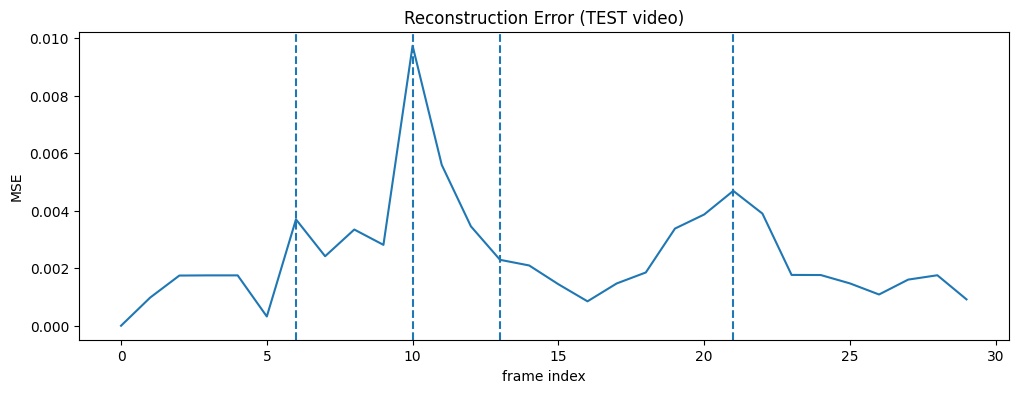

In [ ]:
# visualize reconstruction errors
plt.figure(figsize=(12,4))
plt.plot(errors)
for p in picked:
    plt.axvline(p, linestyle="--")
plt.title("Reconstruction Error")
plt.xlabel("frame index")
plt.ylabel("MSE")
plt.show()

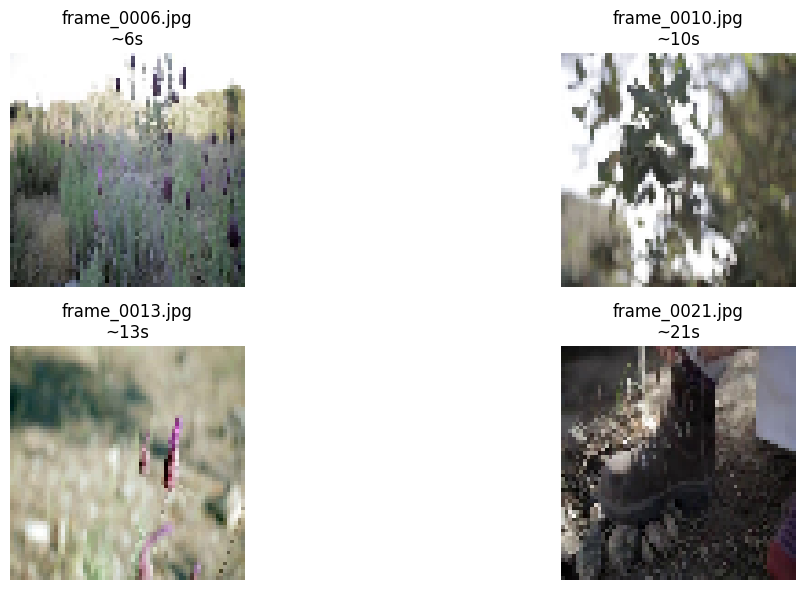

In [ ]:
# display the selected keyframes
plt.figure(figsize=(14,6))
for j, i in enumerate(picked):
    plt.subplot(2, (len(picked)+1)//2, j+1)
    plt.imshow(x_test[i])
    plt.title(f"{frame_files[i]}\n~{i}s")
    plt.axis("off")
plt.tight_layout()
plt.show()